In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivsrijitverma/imagedata2/Cristiano-Ronaldo.avif


In [3]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

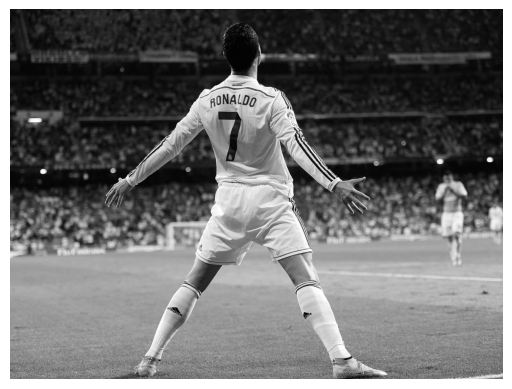

In [6]:
img = cv2.imread("/kaggle/input/datasets/shivsrijitverma/imagedata2/Cristiano-Ronaldo.avif", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

Manual HOG Feature Vector Length: 1753380
Inbuilt HOG Feature Vector Length: 1753380


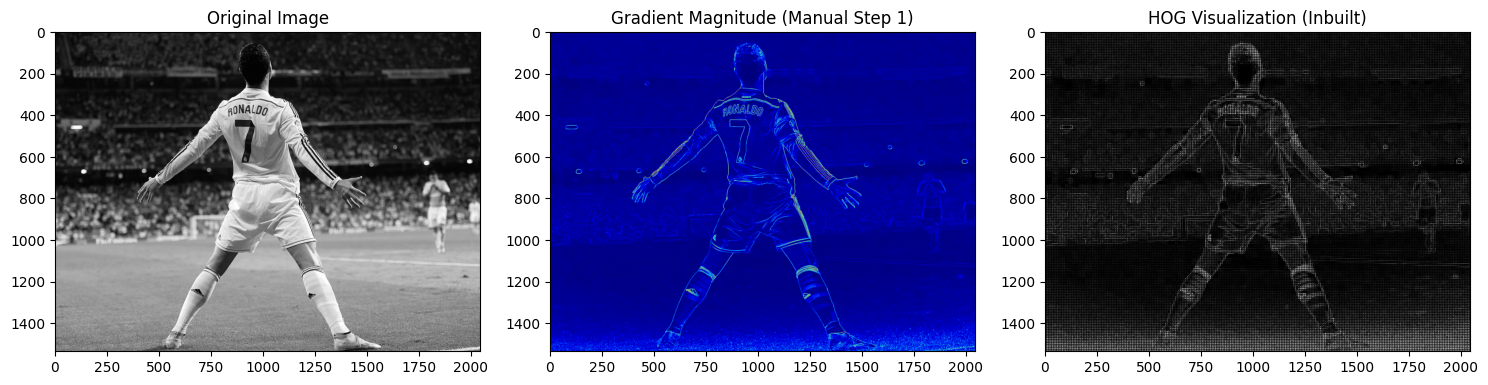

In [8]:
from skimage.feature import hog
from skimage import exposure

def compute_manual_hog(image, cell_size=8, bin_size=9):
    # 1. Gradients
    image = np.float32(image) / 255.0
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=1)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    ang = ang % 180  # Unsigned gradients

    h, w = image.shape 
    num_cells_h = h // cell_size 
    num_cells_w = w // cell_size

    # creating cell histograms 
    histograms = np.zeros((num_cells_h, num_cells_w, bin_size))
    bin_width = 180 // bin_size

    for i in range(num_cells_h):
        for j in range(num_cells_w):
            # extracting cell region 
            cell_mag = mag[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            cell_ang = ang[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]

            # simple binning 
            for r in range(cell_size) : 
                for c in range(cell_size):
                    angle = cell_ang[r,c]
                    magnitude = cell_mag[r,c]
                    bin_idx = int(angle// bin_width) % bin_size
                    histograms[i,j,bin_idx] += magnitude


    # block normalization
    hog_vector = []
    for i in range(num_cells_h - 1):
        for j in range(num_cells_w - 1):
            # Concatenating 4 cells into 1 block (36 features)
            block = histograms[i:i+2, j:j+2, :].flatten()
            # L2 Normalization
            norm = np.sqrt(np.sum(block**2) + 1e-6)
            block_normalized = block / norm
            hog_vector.extend(block_normalized)
            
    return np.array(hog_vector), mag

# Loading image (ensure it's a size divisible by 8 for clean cells)
input_img = img
if input_img is None:
    input_img = np.zeros((128, 128), dtype=np.uint8)
    cv2.putText(input_img, 'IVP', (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 2, 255, 3)

#  Manual Implementation
manual_features, mag_map = compute_manual_hog(input_img)

# Inbuilt Implementation
# Same parameters: 9 bins, 8x8 pixels per cell, 2x2 cells per block
inbuilt_features, hog_viz = hog(input_img, orientations=9, 
                                pixels_per_cell=(8, 8),
                                cells_per_block=(2, 2), 
                                visualize=True, 
                                feature_vector=True)

# 3. Comparison & Display
print(f"Manual HOG Feature Vector Length: {len(manual_features)}")
print(f"Inbuilt HOG Feature Vector Length: {len(inbuilt_features)}")

# Rescaling for visualization
hog_viz_rescaled = exposure.rescale_intensity(hog_viz, in_range=(0, 10))

plt.figure(figsize=(15, 5))
plt.subplot(131), plt.title("Original Image"), plt.imshow(input_img, cmap='gray')
plt.subplot(132), plt.title("Gradient Magnitude (Manual Step 1)"), plt.imshow(mag_map, cmap='jet')
plt.subplot(133), plt.title("HOG Visualization (Inbuilt)"), plt.imshow(hog_viz_rescaled, cmap='gray')
plt.tight_layout()
plt.show()
    

Keypoints detected in Original: 6098
Keypoints detected in Rotated: 5455


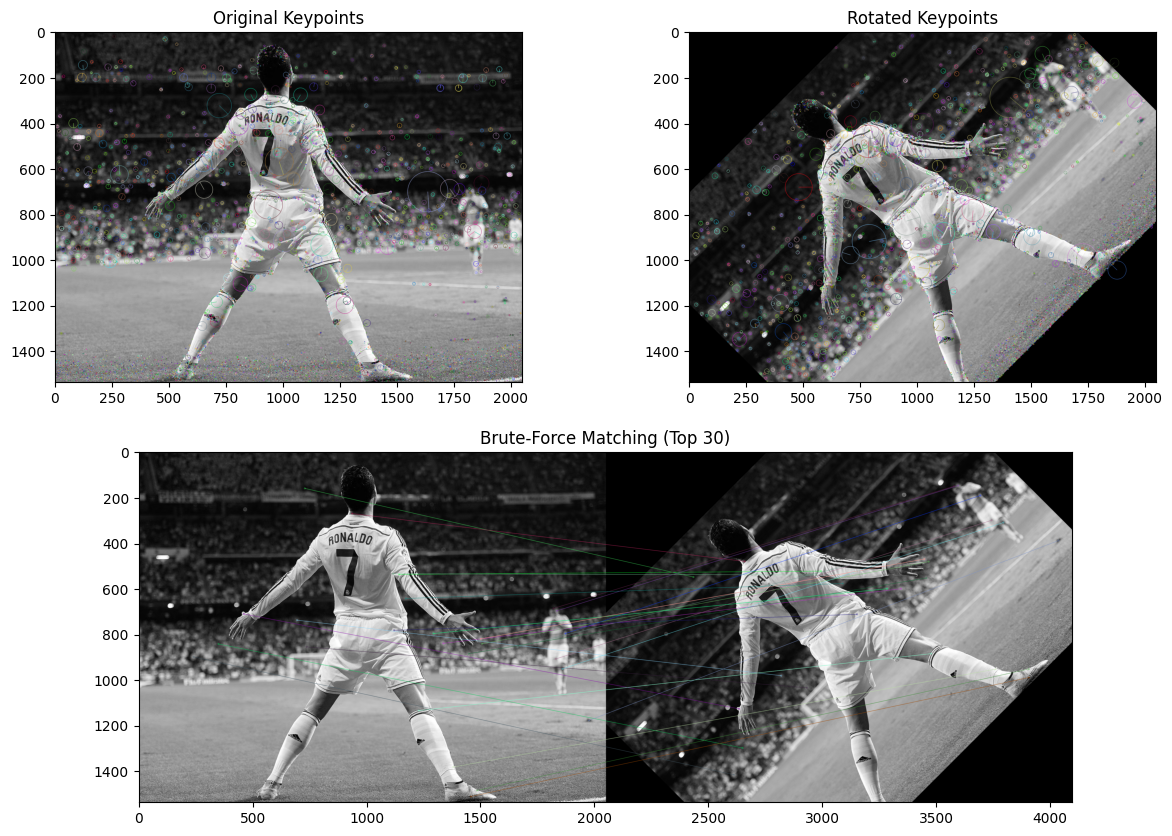

In [9]:
img_original = img
# Generating Rotated Version (45 degrees)
rows, cols = img_original.shape
M = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1) # Center, Angle, Scale
img_rotated = cv2.warpAffine(img_original, M, (cols, rows))

# Initializing SIFT detector
sift = cv2.SIFT_create()

# Detecting keypoints and compute descriptors
kp1, des1 = sift.detectAndCompute(img_original, None)
kp2, des2 = sift.detectAndCompute(img_rotated, None)

print(f"Keypoints detected in Original: {len(kp1)}")
print(f"Keypoints detected in Rotated: {len(kp2)}")

img_kp1 = cv2.drawKeypoints(img_original, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_kp2 = cv2.drawKeypoints(img_rotated, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key = lambda x:x.distance)

img_matches = cv2.drawMatches(img_original, kp1, img_rotated, kp2, matches[:30], None, flags=2)

# Visualization
plt.figure(figsize=(15, 10))
plt.subplot(221), plt.imshow(img_kp1), plt.title("Original Keypoints")
plt.subplot(222), plt.imshow(img_kp2), plt.title("Rotated Keypoints")
plt.subplot(212), plt.imshow(img_matches), plt.title("Brute-Force Matching (Top 30)")
plt.show()